In [1]:
# pip install --upgrade google-cloud-vision
from google.cloud import vision
import matplotlib.pyplot as plt
import cv2

import os
import io

# 1. Set up client
## 1.1. Set key environment

In [2]:
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = "gcp_env/vision-csvc-minhhuunguyen.json"

## 1.2. Create client

In [3]:
client = vision.ImageAnnotatorClient()

In [4]:
client

# 2. Prepare image
## 2.1. Read image bytes

In [5]:
image_path = 'image_test.jpg'

with io.open(image_path, 'rb') as image_file:
    content = image_file.read()

In [6]:
image = vision.Image(content=content)
image

content: "\377\330\377\340\000\020JFIF\000\001\001\001\000H\000H\000\000\377\333\000C\000\007\005\005\006\005\004\007\006\006\006\010\007\007\010\013\022\013\013\n\n\013\026\017\020\r\022\032\026\033\032\031\026\031\030\034 (\"\034\036&\036\030\031#0$&*+-.-\033\"251,5(,-,\377\333\000C\001\007\010\010\013\t\013\025\013\013\025,\035\031\035,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,\377\300\000\021\010\n\343\016|\003\001\"\000\002\021\001\003\021\001\377\304\000\034\000\000\002\002\003\001\001\000\000\000\000\000\000\000\000\000\000\000\001\002\003\004\005\006\007\010\377\304\000T\020\000\002\001\002\004\003\006\004\003\005\005\007\002\003\001\021\000\001\002\003\021\004\005\022!\0061A\023\"2BQq\007\024Ra\025#3$4b\201\221\026CS\241\261\027%5r\202\222\301\010\321&Dc\242\3416s\262\'T\360\361\0307t\203\302\322\223\243\362\377\304\000\033\001\001\001\001\001\001\001\001\001\000\000\000\000\000\000\000\000\000\001\002\003\004\005\006\007\377\304\000/\021\001\001\000\002\001\004\002\002

## 2.2. Read image to visualize

In [7]:
image_cv2 = cv2.imread(image_path)
image_cv2 = cv2.cvtColor(image_cv2, cv2.COLOR_BGR2RGB)

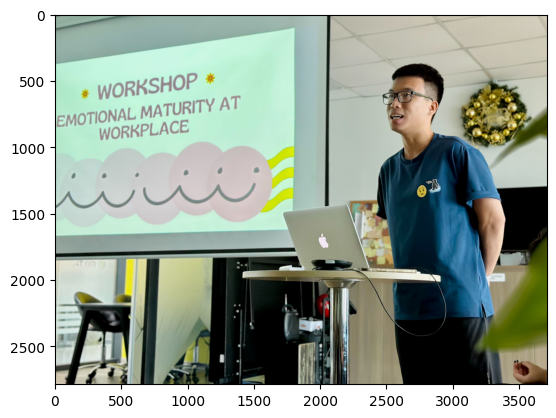

In [8]:
plt.imshow(image_cv2)

# 3. Run Face Detection
## 3.1. Predict - Call API

In [9]:
response = client.face_detection(image=image)
response

face_annotations {
  bounding_poly {
    vertices {
      x: 2438
      y: 362
    }
    vertices {
      x: 2927
      y: 362
    }
    vertices {
      x: 2927
      y: 930
    }
    vertices {
      x: 2438
      y: 930
    }
  }
  fd_bounding_poly {
    vertices {
      x: 2486
      y: 502
    }
    vertices {
      x: 2873
      y: 502
    }
    vertices {
      x: 2873
      y: 891
    }
    vertices {
      x: 2486
      y: 891
    }
  }
  landmarks {
    type_: LEFT_EYE
    position {
      x: 2533.96167
      y: 619.889893
      z: -0.000870704651
    }
  }
  landmarks {
    type_: RIGHT_EYE
    position {
      x: 2647.69141
      y: 612.751465
      z: -91.8535614
    }
  }
  landmarks {
    type_: LEFT_OF_LEFT_EYEBROW
    position {
      x: 2510.25806
      y: 584.5448
      z: 45.8196
    }
  }
  landmarks {
    type_: RIGHT_OF_LEFT_EYEBROW
    position {
      x: 2554.81543
      y: 580.77478
      z: -42.551384
    }
  }
  landmarks {
    type_: LEFT_OF_RIGHT_EYEBROW
 

In [10]:
response.face_annotations # list prediction of all faces
len(response.face_annotations)

1

In [11]:
response.face_annotations[0].bounding_poly # head detection

vertices {
  x: 2438
  y: 362
}
vertices {
  x: 2927
  y: 362
}
vertices {
  x: 2927
  y: 930
}
vertices {
  x: 2438
  y: 930
}

In [12]:
response.face_annotations[0].fd_bounding_poly # face detection

vertices {
  x: 2486
  y: 502
}
vertices {
  x: 2873
  y: 502
}
vertices {
  x: 2873
  y: 891
}
vertices {
  x: 2486
  y: 891
}

In [13]:
response.face_annotations[0].landmarks

[type_: LEFT_EYE
position {
  x: 2533.96167
  y: 619.889893
  z: -0.000870704651
}
, type_: RIGHT_EYE
position {
  x: 2647.69141
  y: 612.751465
  z: -91.8535614
}
, type_: LEFT_OF_LEFT_EYEBROW
position {
  x: 2510.25806
  y: 584.5448
  z: 45.8196
}
, type_: RIGHT_OF_LEFT_EYEBROW
position {
  x: 2554.81543
  y: 580.77478
  z: -42.551384
}
, type_: LEFT_OF_RIGHT_EYEBROW
position {
  x: 2608.35327
  y: 574.073914
  z: -85.8726349
}
, type_: RIGHT_OF_RIGHT_EYEBROW
position {
  x: 2706.94556
  y: 577.575195
  z: -110.442871
}
, type_: MIDPOINT_BETWEEN_EYES
position {
  x: 2578.39331
  y: 609.923157
  z: -69.7653809
}
, type_: NOSE_TIP
position {
  x: 2552.05908
  y: 686.309082
  z: -112.998138
}
, type_: UPPER_LIP
position {
  x: 2562.58984
  y: 742.823914
  z: -93.5653152
}
, type_: LOWER_LIP
position {
  x: 2564.23975
  y: 802.737854
  z: -92.5979462
}
, type_: MOUTH_LEFT
position {
  x: 2535.78101
  y: 778.779907
  z: -29.3955135
}
, type_: MOUTH_RIGHT
position {
  x: 2630.01172
  y: 77

## 3.2. Visualize prediction

bounding_poly x: 2438
y: 362

bounding_poly x: 2927
y: 362

bounding_poly x: 2927
y: 930

bounding_poly x: 2438
y: 930

fd_bounding_poly x: 2486
y: 502

fd_bounding_poly x: 2873
y: 502

fd_bounding_poly x: 2873
y: 891

fd_bounding_poly x: 2486
y: 891



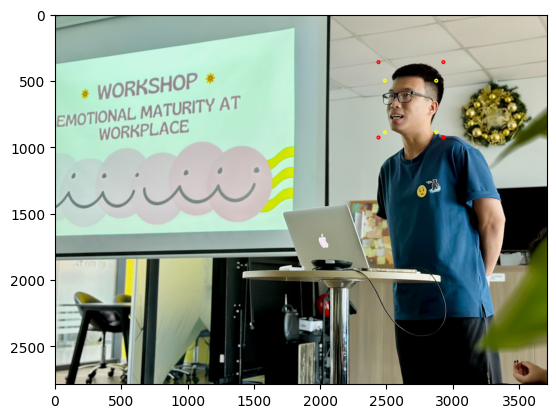

In [14]:
for face_anno in response.face_annotations:
    for point in face_anno.bounding_poly.vertices:
        print('bounding_poly', point)
        image_cv2 = cv2.circle(
            img=image_cv2,
            center=(point.x, point.y),
            radius=10,
            color=(255, 0, 0),
            thickness=10
        )
    for point in face_anno.fd_bounding_poly.vertices:
        print('fd_bounding_poly', point)
        image_cv2 = cv2.circle(
            img=image_cv2,
            center=(point.x, point.y),
            radius=10,
            color=(255, 255, 0),
            thickness=10
        )

plt.imshow(image_cv2)

# 4. Run Text detection
## 4.1. Predict - Call API

In [15]:
response = client.text_detection(image=image)
response

text_annotations {
  locale: "en"
  description: "* WORKSHOP *\nEMOTIONAL MATURITY AT\nWORKPLACE\nAT (198\nتن"
  bounding_poly {
    vertices {
      x: -15
      y: 403
    }
    vertices {
      x: 1408
      y: 403
    }
    vertices {
      x: 1408
      y: 1914
    }
    vertices {
      x: -15
      y: 1914
    }
  }
}
text_annotations {
  description: "*"
  bounding_poly {
    vertices {
      x: 195
      y: 546
    }
    vertices {
      x: 246
      y: 540
    }
    vertices {
      x: 260
      y: 656
    }
    vertices {
      x: 209
      y: 662
    }
  }
}
text_annotations {
  description: "WORKSHOP"
  bounding_poly {
    vertices {
      x: 319
      y: 530
    }
    vertices {
      x: 1069
      y: 439
    }
    vertices {
      x: 1083
      y: 556
    }
    vertices {
      x: 333
      y: 647
    }
  }
}
text_annotations {
  description: "*"
  bounding_poly {
    vertices {
      x: 1133
      y: 432
    }
    vertices {
      x: 1190
      y: 425
    }
    vertices

In [16]:
response.text_annotations # list of text on image
len(response.text_annotations)

12

In [17]:
response.text_annotations[0]

locale: "en"
description: "* WORKSHOP *\nEMOTIONAL MATURITY AT\nWORKPLACE\nAT (198\nتن"
bounding_poly {
  vertices {
    x: -15
    y: 403
  }
  vertices {
    x: 1408
    y: 403
  }
  vertices {
    x: 1408
    y: 1914
  }
  vertices {
    x: -15
    y: 1914
  }
}

In [18]:
response.text_annotations[0].bounding_poly # text detection

vertices {
  x: -15
  y: 403
}
vertices {
  x: 1408
  y: 403
}
vertices {
  x: 1408
  y: 1914
}
vertices {
  x: -15
  y: 1914
}

In [19]:
response.text_annotations[0].description # text recognition - OCR

'* WORKSHOP *\nEMOTIONAL MATURITY AT\nWORKPLACE\nAT (198\nتن'

In [20]:
response.text_annotations[0].locale # language classification

'en'

## 4.2. Visualize prediction

In [21]:
color_value = 40
for text_anno in response.text_annotations:
    print(text_anno.description, text_anno.locale)
    color_value -= 5
    for point in text_anno.bounding_poly.vertices:
        print('bounding_poly', point)
        image_cv2 = cv2.circle(
            img=image_cv2,
            center=(point.x, point.y),
            radius=10,
            color=(color_value, color_value, color_value),
            thickness=10
        )

* WORKSHOP *
EMOTIONAL MATURITY AT
WORKPLACE
AT (198
تن en
bounding_poly x: -15
y: 403

bounding_poly x: 1408
y: 403

bounding_poly x: 1408
y: 1914

bounding_poly x: -15
y: 1914

* 
bounding_poly x: 195
y: 546

bounding_poly x: 246
y: 540

bounding_poly x: 260
y: 656

bounding_poly x: 209
y: 662

WORKSHOP 
bounding_poly x: 319
y: 530

bounding_poly x: 1069
y: 439

bounding_poly x: 1083
y: 556

bounding_poly x: 333
y: 647

* 
bounding_poly x: 1133
y: 432

bounding_poly x: 1190
y: 425

bounding_poly x: 1204
y: 541

bounding_poly x: 1147
y: 548

EMOTIONAL 
bounding_poly x: 8
y: 763

bounding_poly x: 600
y: 698

bounding_poly x: 611
y: 797

bounding_poly x: 19
y: 862

MATURITY 
bounding_poly x: 633
y: 694

bounding_poly x: 1201
y: 631

bounding_poly x: 1212
y: 731

bounding_poly x: 644
y: 793

AT 
bounding_poly x: 1225
y: 629

bounding_poly x: 1396
y: 610

bounding_poly x: 1407
y: 709

bounding_poly x: 1236
y: 727

WORKPLACE 
bounding_poly x: 324
y: 857

bounding_poly x: 1000
y: 792

bound

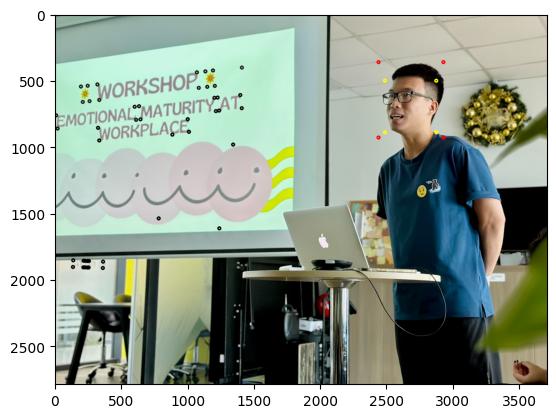

In [22]:
plt.imshow(image_cv2)

# 5. Run logo detection

In [23]:
response = client.logo_detection(image=image)
response

In [24]:
response

# 6. Run label detection

In [25]:
response = client.label_detection(image=image)
response

label_annotations {
  mid: "/m/01c648"
  description: "Laptop"
  score: 0.939344585
  topicality: 0.939344585
}
label_annotations {
  mid: "/m/01m3v"
  description: "Computer"
  score: 0.930407822
  topicality: 0.930407822
}
label_annotations {
  mid: "/m/0643t"
  description: "Personal computer"
  score: 0.869722188
  topicality: 0.869722188
}
label_annotations {
  mid: "/m/04bcr3"
  description: "Table"
  score: 0.862052083
  topicality: 0.862052083
}
label_annotations {
  mid: "/m/088fh"
  description: "Yellow"
  score: 0.841303587
  topicality: 0.841303587
}
label_annotations {
  mid: "/m/02mf1n"
  description: "Gadget"
  score: 0.757457197
  topicality: 0.757457197
}
label_annotations {
  mid: "/m/081pkj"
  description: "Event"
  score: 0.753316343
  topicality: 0.753316343
}
label_annotations {
  mid: "/m/07c1v"
  description: "Technology"
  score: 0.751444221
  topicality: 0.751444221
}
label_annotations {
  mid: "/m/02ky346"
  description: "Engineering"
  score: 0.746686161
  t

In [26]:
for anno in response.label_annotations:
    print(anno.description, anno.score)

Laptop 0.939344584941864
Computer 0.9304078221321106
Personal computer 0.8697221875190735
Table 0.8620520830154419
Yellow 0.8413035869598389
Gadget 0.7574571967124939
Event 0.753316342830658
Technology 0.7514442205429077
Engineering 0.7466861605644226
Stage equipment 0.7299929857254028


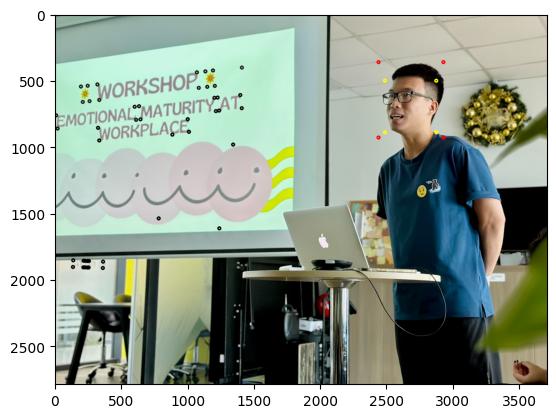

In [27]:
plt.imshow(image_cv2)